# Heart Disease Prediction Using a Deep Neural Network

## Dissertation Code — Neural Network Classifier

This notebook implements a high-performance neural network for binary classification of heart disease risk.  
The pipeline covers data loading, cleaning, exploratory analysis, feature engineering, model training with PyTorch, hyperparameter tuning, evaluation, interpretability (SHAP), and clinical threshold optimisation.

**Target column:** `HeartDisease` (1 = at risk, 0 = not at risk)

**Dataset:** 918 patient records from the UCI / Kaggle Heart Failure Prediction Dataset.

In [1]:
# =============================================================================
# 1. IMPORTS
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

# SHAP for interpretability
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

print("All imports successful.")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

All imports successful.
PyTorch version: 2.10.0+cu128
Device: CPU


## 2. Load and Inspect the Dataset

In [2]:
# =============================================================================
# 2. LOAD AND INSPECT THE DATASET
# =============================================================================
heart_data = pd.read_csv("heart.csv")

print(f"Dataset shape: {heart_data.shape}")
print(f"\nFirst 5 rows:")
display(heart_data.head())

print(f"\nData types:\n{heart_data.dtypes}")
print(f"\nBasic statistics:")
display(heart_data.describe())
print(f"\nMissing values:\n{heart_data.isnull().sum()}")
print(f"\nDuplicate rows: {heart_data.duplicated().sum()}")

# Confirm target column and binary classification task
print(f"\nTarget column 'HeartDisease' unique values: {heart_data['HeartDisease'].unique()}")
print(f"Class distribution:\n{heart_data['HeartDisease'].value_counts()}")
print(f"\nThis is a BINARY CLASSIFICATION task: predict HeartDisease = 1 (at risk) vs 0 (not at risk).")

Dataset shape: (918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



Data types:
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

Basic statistics:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000



Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0

Target column 'HeartDisease' unique values: [0 1]
Class distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

This is a BINARY CLASSIFICATION task: predict HeartDisease = 1 (at risk) vs 0 (not at risk).


## 3. Data Cleaning

- Remove duplicate rows  
- Handle outliers using IQR capping (same approach as the Random Forest notebook for consistency)  
- Fix implausible zero values in RestingBP and Cholesterol (replace with median)

Removed 0 duplicate rows. Remaining: 918
Replaced 1 zero values in 'RestingBP' with median (130.0)
Replaced 172 zero values in 'Cholesterol' with median (237.0)

Outlier capping (IQR method):
  Age: clipped 0 values to [27.5, 79.5]
  RestingBP: clipped 27 values to [90.0, 170.0]
  Cholesterol: clipped 41 values to [134.5, 346.5]
  MaxHR: clipped 2 values to [66.0, 210.0]
  Oldpeak: clipped 16 values to [-2.2, 3.8]


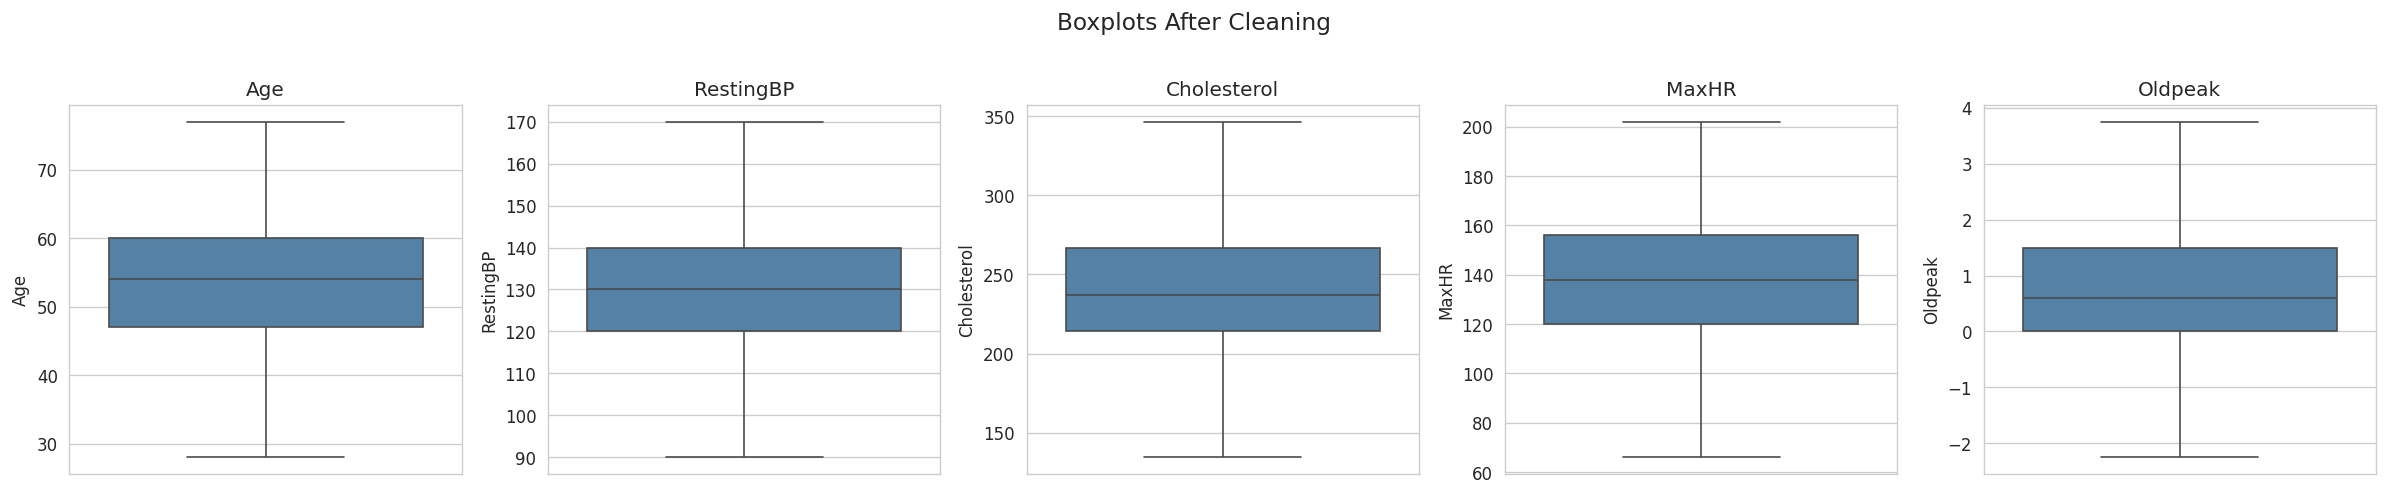


Final cleaned dataset shape: (918, 12)


In [3]:
# =============================================================================
# 3. DATA CLEANING
# =============================================================================

# 3a. Remove duplicates
n_before = len(heart_data)
heart_data = heart_data.drop_duplicates().reset_index(drop=True)
print(f"Removed {n_before - len(heart_data)} duplicate rows. Remaining: {len(heart_data)}")

# 3b. Fix implausible zero values
# RestingBP = 0 and Cholesterol = 0 are physiologically impossible; treat as missing
for col in ['RestingBP', 'Cholesterol']:
    n_zeros = (heart_data[col] == 0).sum()
    if n_zeros > 0:
        median_val = heart_data.loc[heart_data[col] > 0, col].median()
        heart_data.loc[heart_data[col] == 0, col] = median_val
        print(f"Replaced {n_zeros} zero values in '{col}' with median ({median_val})")

# 3c. Outlier handling using IQR capping
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
print("\nOutlier capping (IQR method):")
for col in numeric_cols:
    Q1 = heart_data[col].quantile(0.25)
    Q3 = heart_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_clipped = ((heart_data[col] < lower) | (heart_data[col] > upper)).sum()
    heart_data[col] = heart_data[col].clip(lower, upper)
    print(f"  {col}: clipped {n_clipped} values to [{lower:.1f}, {upper:.1f}]")

# 3d. Visualise cleaned numeric distributions
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=heart_data[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}')
plt.suptitle("Boxplots After Cleaning", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFinal cleaned dataset shape: {heart_data.shape}")

## 4. Exploratory Data Analysis (EDA)

- Class balance check  
- Feature distributions by class  
- Correlation heatmap  
- Pairwise relationships

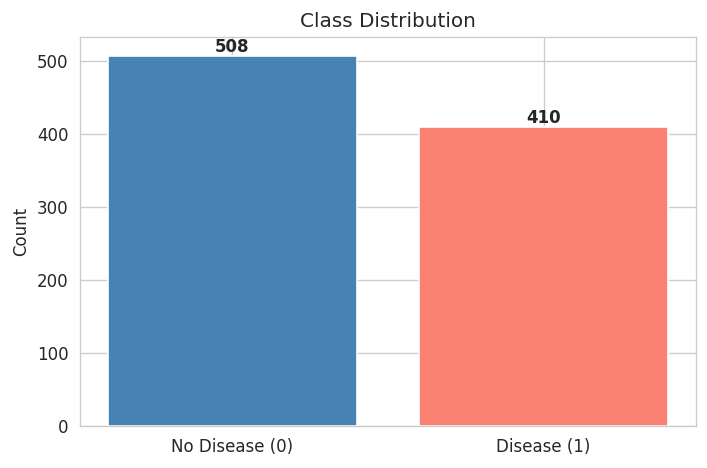

Class ratio (minority / majority): 0.81
=> Classes are reasonably balanced.


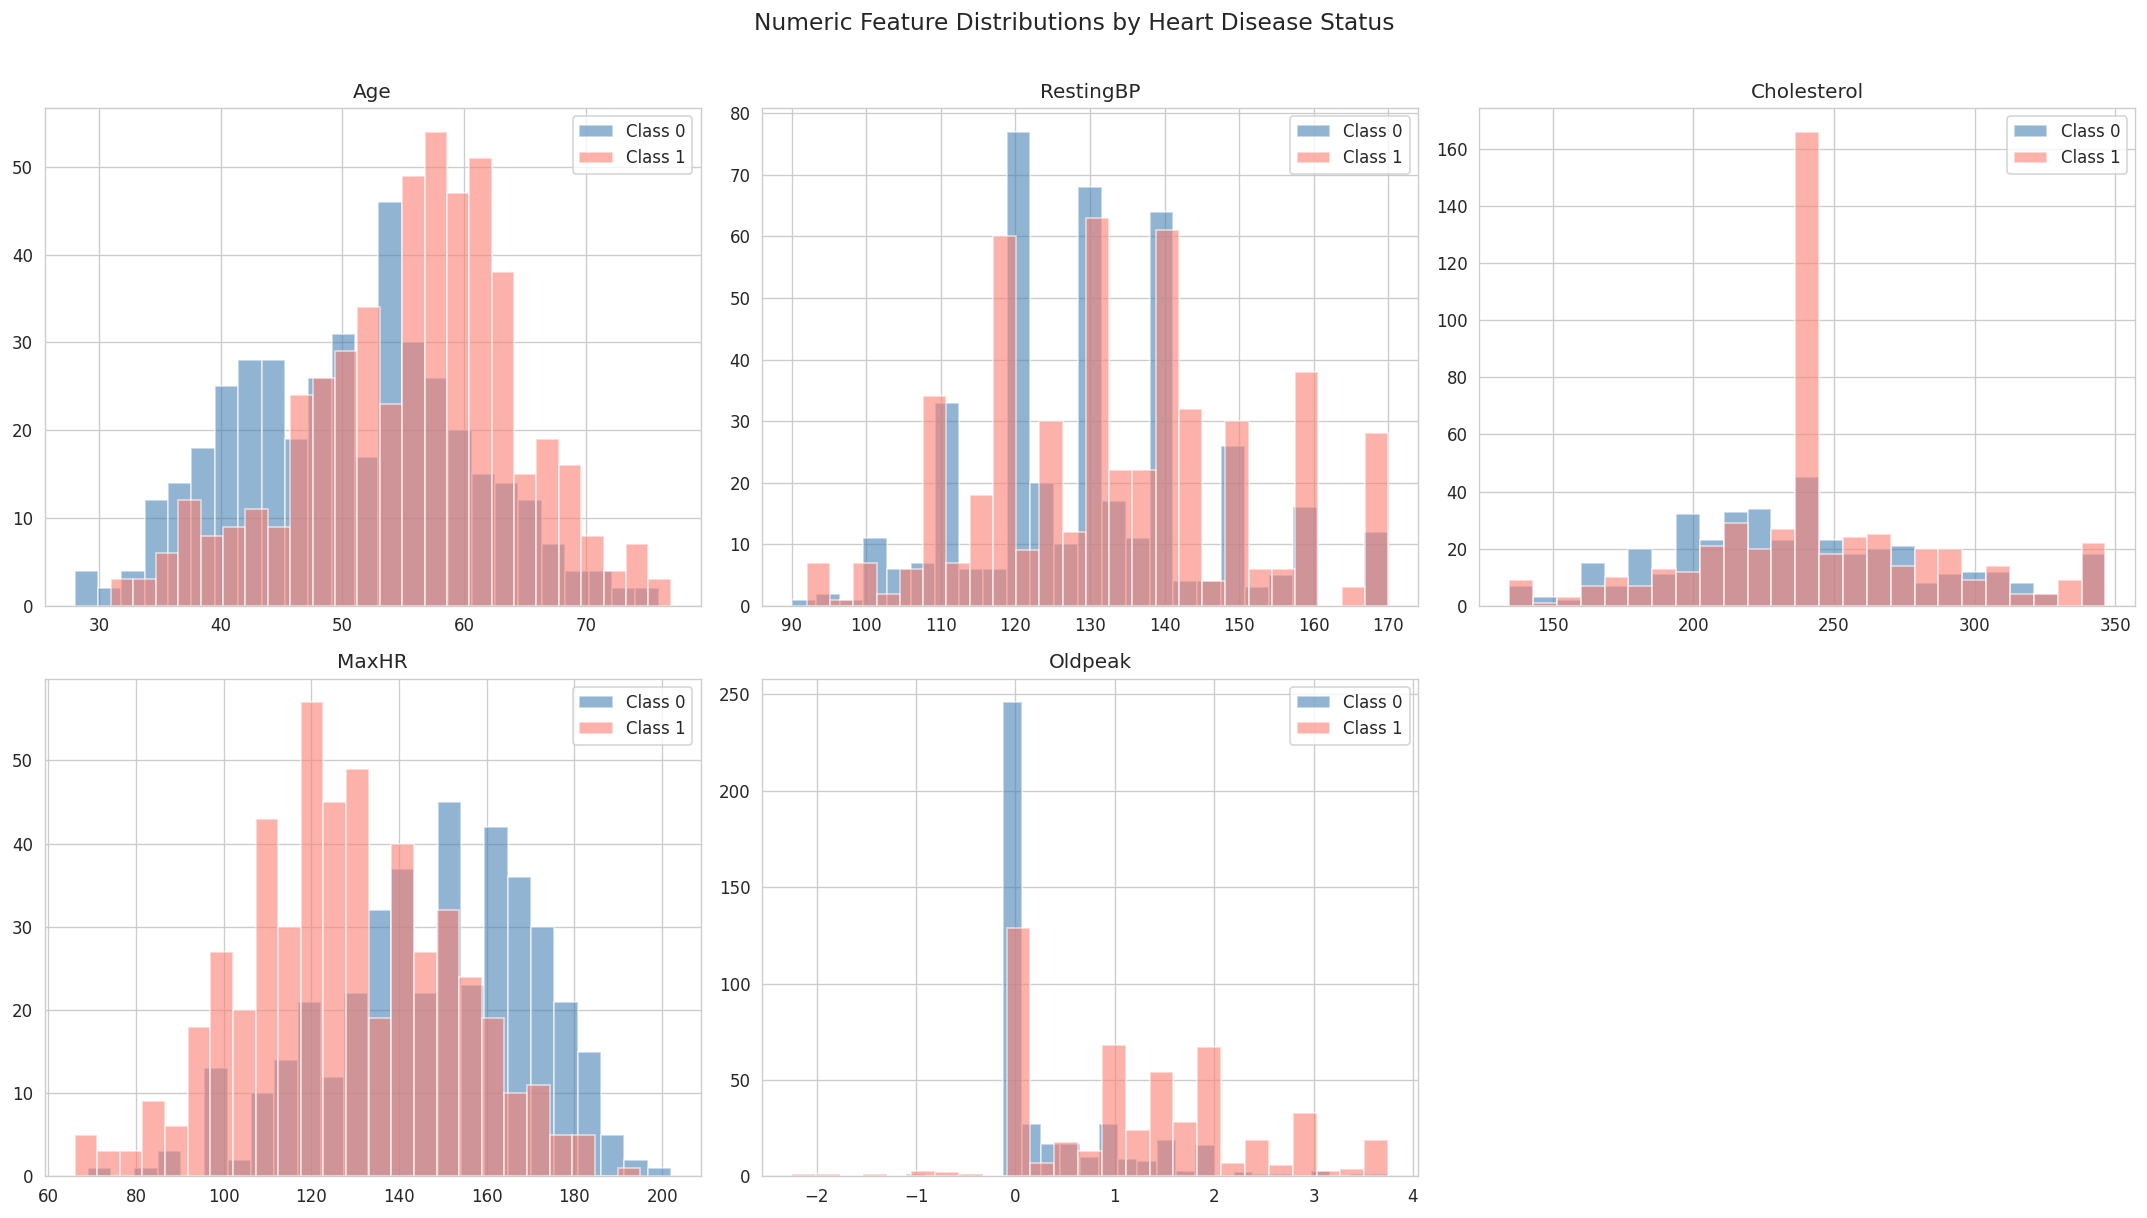

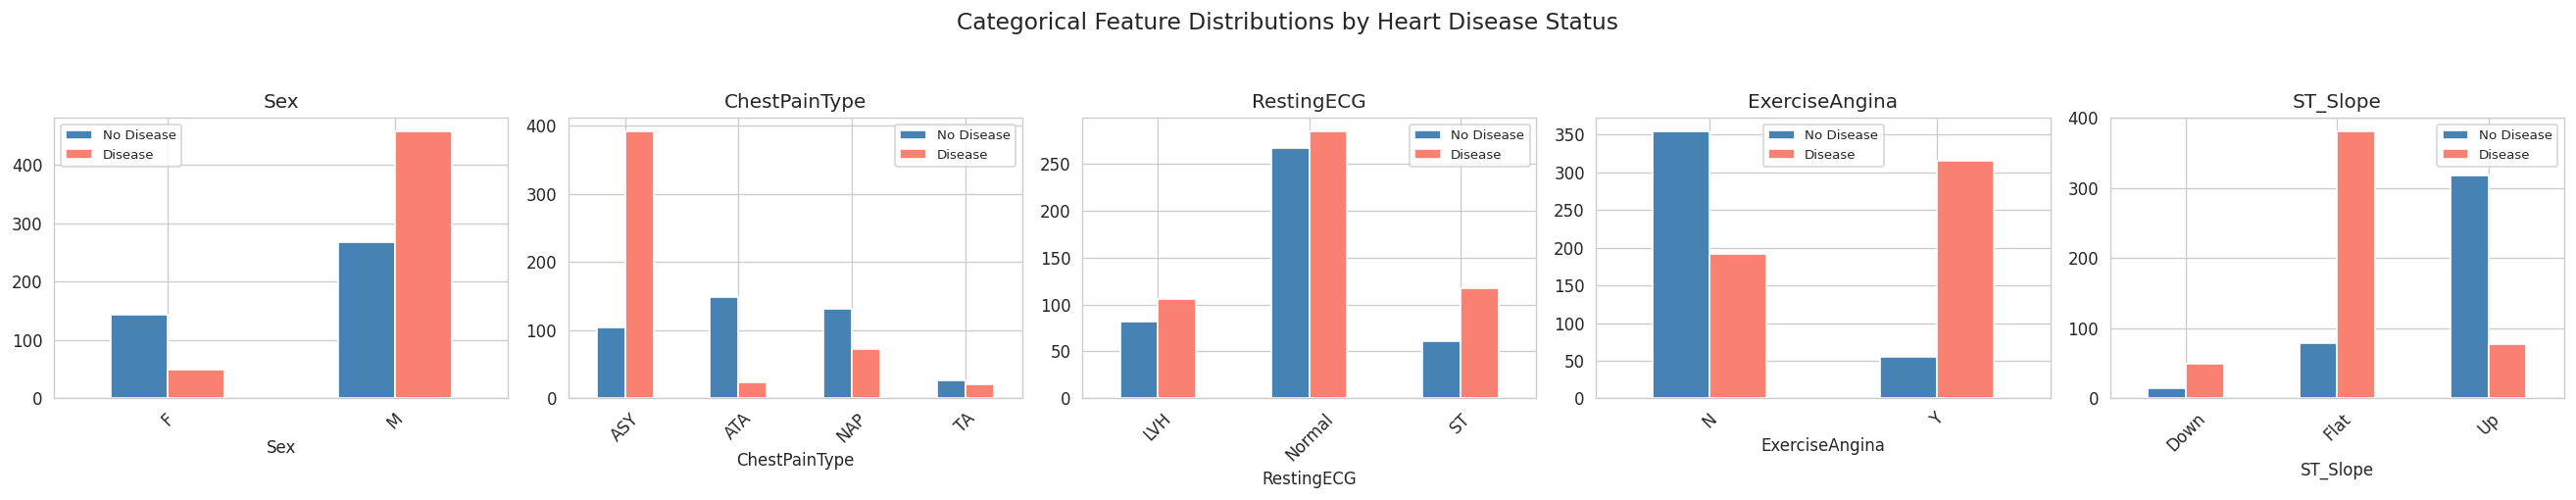

In [4]:
# =============================================================================
# 4. EXPLORATORY DATA ANALYSIS
# =============================================================================

# 4a. Class balance
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
counts = heart_data['HeartDisease'].value_counts()
bars = ax.bar(['No Disease (0)', 'Disease (1)'], counts.values, color=['steelblue', 'salmon'])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val),
            ha='center', fontweight='bold')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

imbalance_ratio = counts.min() / counts.max()
print(f"Class ratio (minority / majority): {imbalance_ratio:.2f}")
print(f"{'=> Moderate imbalance detected. Will use class weights.' if imbalance_ratio < 0.8 else '=> Classes are reasonably balanced.'}")

# 4b. Numeric feature distributions by class
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    for label, color in [(0, 'steelblue'), (1, 'salmon')]:
        subset = heart_data[heart_data['HeartDisease'] == label][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=f'Class {label}')
    ax.set_title(col)
    ax.legend()
axes[1][2].axis('off')
plt.suptitle("Numeric Feature Distributions by Heart Disease Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 4c. Categorical feature distributions by class
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, col in enumerate(cat_cols):
    pd.crosstab(heart_data[col], heart_data['HeartDisease']).plot(
        kind='bar', ax=axes[i], color=['steelblue', 'salmon'])
    axes[i].set_title(col)
    axes[i].legend(['No Disease', 'Disease'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle("Categorical Feature Distributions by Heart Disease Status", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

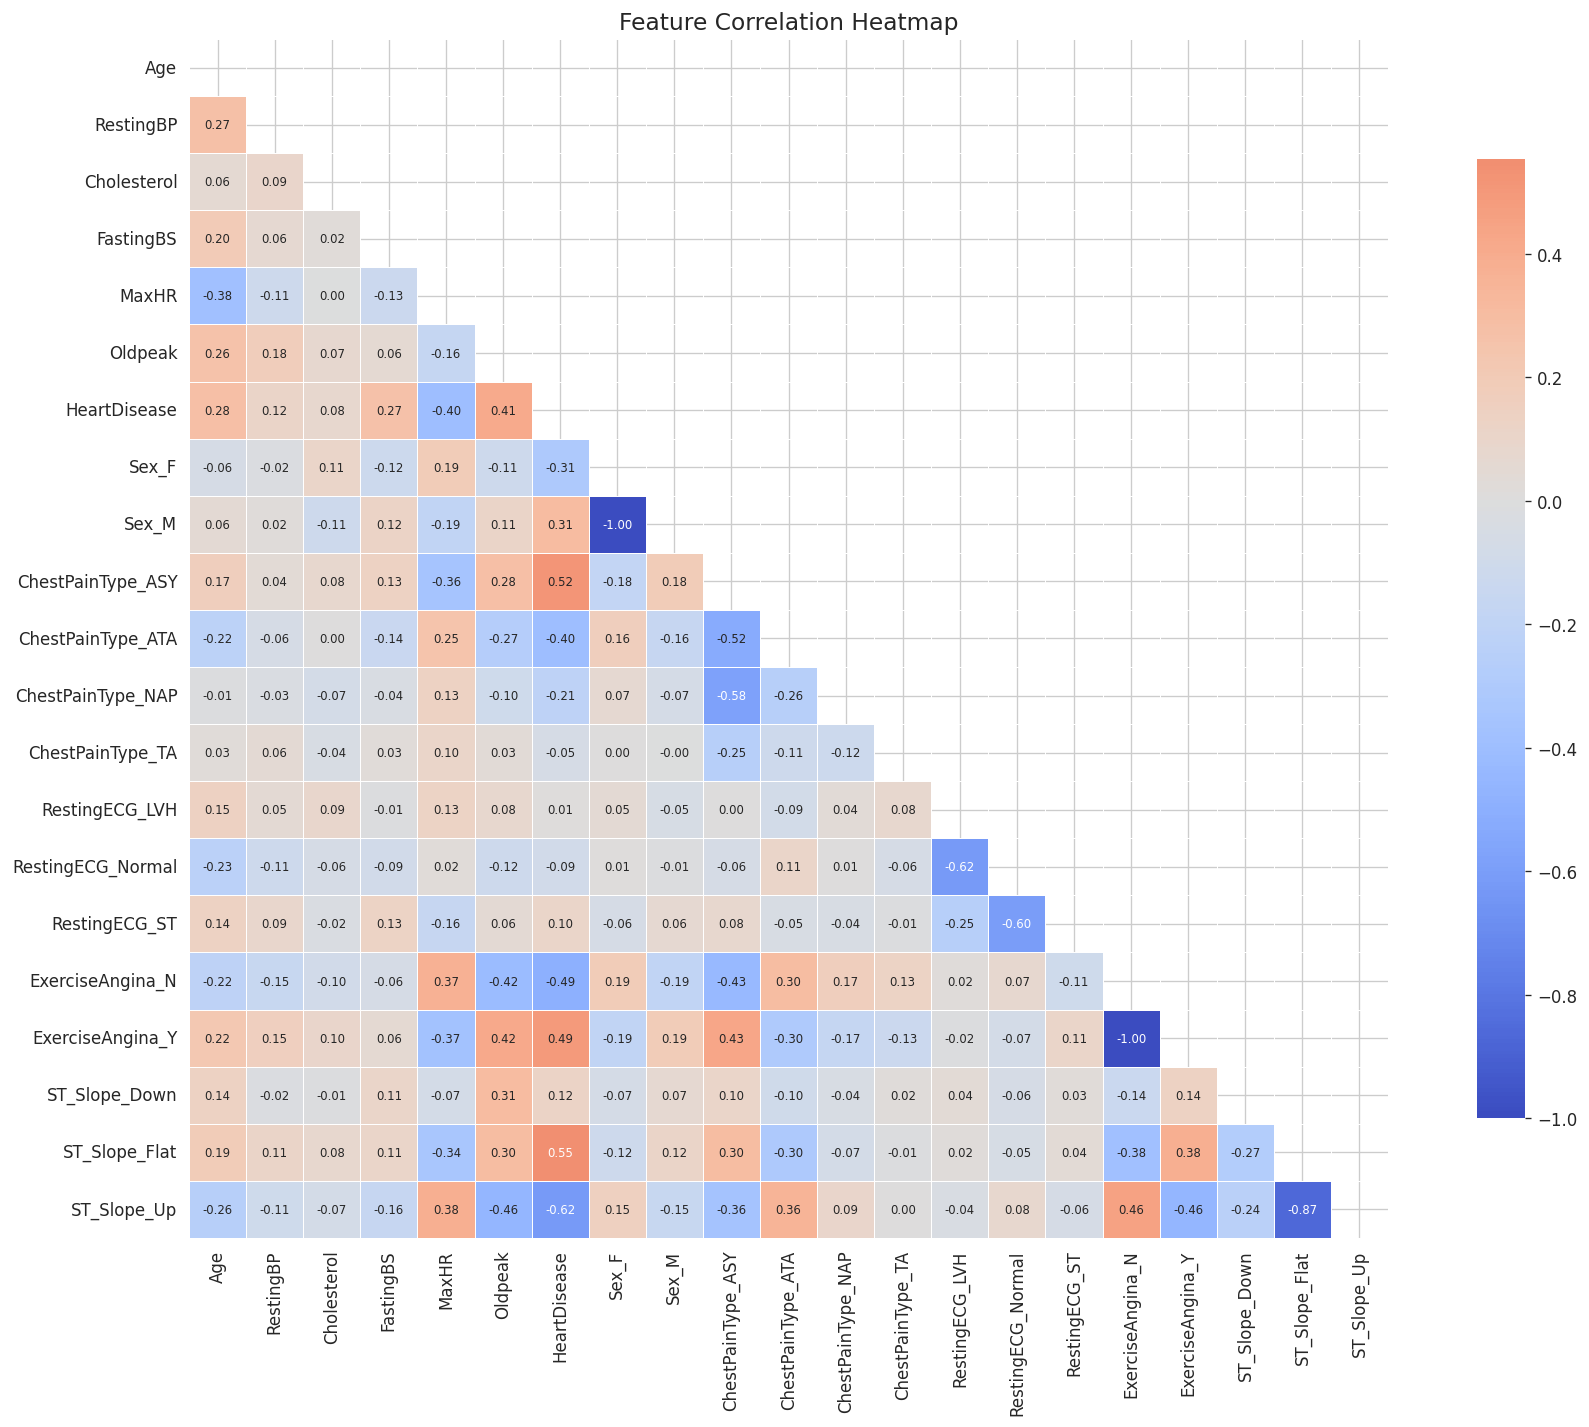

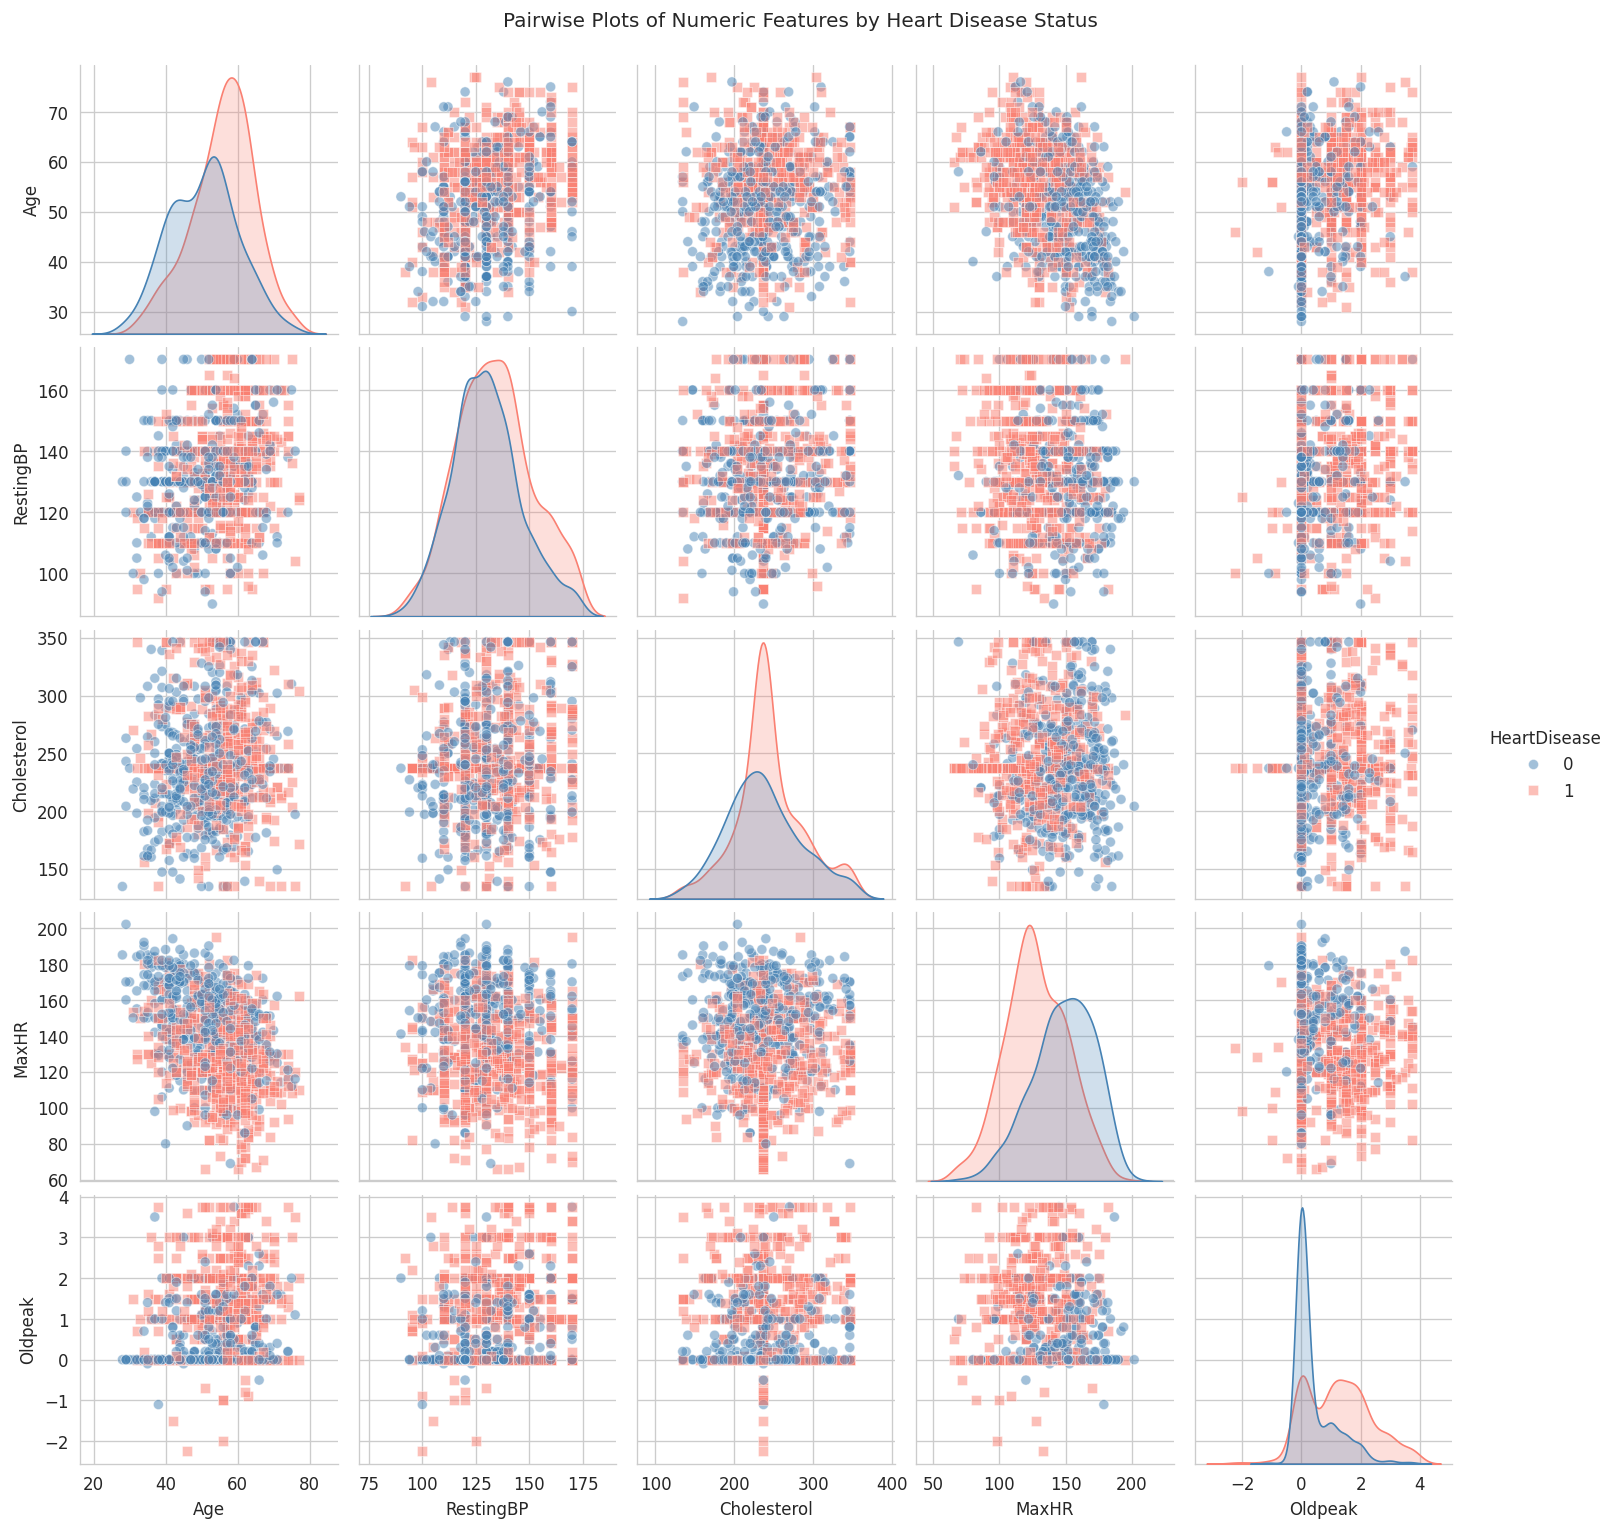

In [5]:
# 4d. Correlation heatmap (on encoded data for a preview)
heart_encoded_preview = pd.get_dummies(heart_data, columns=cat_cols)
plt.figure(figsize=(16, 12))
corr = heart_encoded_preview.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7})
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

# 4e. Pairwise scatter plot of key numeric features
subset = heart_data[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']]
sns.pairplot(subset, hue='HeartDisease', markers=["o", "s"],
             palette={0: 'steelblue', 1: 'salmon'}, plot_kws={'alpha': 0.5})
plt.suptitle("Pairwise Plots of Numeric Features by Heart Disease Status", y=1.02)
plt.show()

## 5. Feature Engineering and Preprocessing

- One-hot encode categorical features  
- Standard-scale numerical features  
- Split into train (64%), validation (16%), and test (20%) sets  
- Compute class weights for handling imbalance

In [6]:
# =============================================================================
# 5. FEATURE ENGINEERING AND PREPROCESSING
# =============================================================================

# 5a. One-hot encode categorical features
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
heart_encoded = pd.get_dummies(heart_data, columns=cat_cols, drop_first=False).astype(float)

# Separate features and target
X = heart_encoded.drop('HeartDisease', axis=1)
y = heart_encoded['HeartDisease'].values.astype(float)

feature_names = X.columns.tolist()
print(f"Number of features after encoding: {len(feature_names)}")
print(f"Features: {feature_names}")

# 5b. Train / Validation / Test split (64% / 16% / 20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=SEED, stratify=y_train_val)

print(f"\nSplit sizes:")
print(f"  Train:      {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test:       {X_test.shape[0]} samples")

# 5c. Standard scaling (fit on train only to avoid data leakage)
scaler = StandardScaler()
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val[numeric_features] = scaler.transform(X_val[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# 5d. Compute class weights to handle imbalance
classes = np.array([0, 1])
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}
print(f"\nClass weights: {class_weight_dict}")

# 5e. Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train.values.astype(np.float32)).to(device)
y_train_t = torch.FloatTensor(y_train.astype(np.float32)).to(device)
X_val_t = torch.FloatTensor(X_val.values.astype(np.float32)).to(device)
y_val_t = torch.FloatTensor(y_val.astype(np.float32)).to(device)
X_test_t = torch.FloatTensor(X_test.values.astype(np.float32)).to(device)
y_test_t = torch.FloatTensor(y_test.astype(np.float32)).to(device)

# Create weighted sampler for training (handles class imbalance during batching)
sample_weights = np.array([class_weight_dict[int(label)] for label in y_train])
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train.shape[1]
print(f"\nInput dimension: {input_dim}")
print("Preprocessing complete.")

Number of features after encoding: 20
Features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']

Split sizes:
  Train:      587 samples
  Validation: 147 samples
  Test:       184 samples

Class weights: {0: 1.1202290076335877, 1: 0.9030769230769231}

Input dimension: 20
Preprocessing complete.


## 6. Neural Network Model Definition

**Architecture:** A deep feedforward neural network with residual (skip) connections, designed for tabular data.

Key design choices for a small tabular dataset:
- **Batch Normalisation** after each hidden layer for stable training  
- **Dropout** (0.3–0.5) for strong regularisation to prevent overfitting  
- **Residual connections** so the network can learn identity mappings and train deeper  
- **GELU activation** (smoother than ReLU, often better on tabular data)  
- **Weighted BCE loss** to penalise missing true positives more heavily  
- **Learning rate scheduling** with cosine annealing  
- **Early stopping** on validation loss to prevent overfitting  

**Note on dataset size:** With ~918 samples, deep learning has limited advantage over tree-based methods. However, with careful regularisation and the architecture choices above, a well-tuned neural network can match or exceed simpler models while offering probability calibration and gradient-based interpretability.

In [7]:
# =============================================================================
# 6. NEURAL NETWORK MODEL DEFINITION
# =============================================================================

class ResidualBlock(nn.Module):
    """A residual block with BatchNorm, GELU activation, and Dropout."""
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Skip connection: add input to block output
        return self.dropout(self.activation(self.block(x) + x))


class HeartDiseaseNet(nn.Module):
    """
    Deep feedforward neural network with residual connections for tabular
    binary classification.
    
    Architecture:
        Input -> Expand -> [ResidualBlock] x N -> Compress -> Output (sigmoid)
    """
    def __init__(self, input_dim, hidden_dim=128, n_blocks=3, dropout=0.4):
        super().__init__()
        
        # Input projection layer (expand to hidden_dim)
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Stack of residual blocks
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim, dropout) for _ in range(n_blocks)]
        )
        
        # Output head (compress to prediction)
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_blocks(x)
        x = self.output_head(x)
        return x  # Raw logits (BCEWithLogitsLoss applies sigmoid internally)


# Instantiate the model
model = HeartDiseaseNet(
    input_dim=input_dim,
    hidden_dim=128,
    n_blocks=3,
    dropout=0.4
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model architecture:
HeartDiseaseNet(
  (input_layer): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.4, inplace=False)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.4, inplace=False)
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (activation): GELU(approximate='none')
      (dropout): Dropout(p=0.4, inplace=False)
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
   

## 7. Training Loop with Early Stopping

In [8]:
# =============================================================================
# 7. TRAINING LOOP WITH EARLY STOPPING
# =============================================================================

def train_model(model, train_loader, val_loader, X_val_t, y_val_t,
                class_weight_dict, epochs=300, lr=1e-3, patience=30):
    """
    Train the neural network with:
    - Weighted BCE loss (higher penalty for missing disease cases)
    - AdamW optimiser with weight decay
    - Cosine annealing learning rate schedule
    - Early stopping based on validation loss
    """
    # Weighted loss: pos_weight = weight_class_1 / weight_class_0
    pos_weight = torch.FloatTensor([class_weight_dict[1] / class_weight_dict[0]]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    optimiser = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs, eta_min=1e-6)
    
    # Tracking
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        # --- Training phase ---
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0
        
        for X_batch, y_batch in train_loader:
            optimiser.zero_grad()
            logits = model(X_batch).squeeze()
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            
            epoch_loss += loss.item() * len(y_batch)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
        
        train_loss = epoch_loss / total
        train_acc = correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # --- Validation phase ---
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t).squeeze()
            val_loss = criterion(val_logits, y_val_t).item()
            val_preds = (torch.sigmoid(val_logits) >= 0.5).float()
            val_acc = (val_preds == y_val_t).sum().item() / len(y_val_t)
        
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        scheduler.step()
        
        # --- Early stopping check ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if (epoch + 1) % 25 == 0 or epoch == 0:
            lr_now = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
                  f"LR: {lr_now:.6f}")
        
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break
    
    # Restore best model
    model.load_state_dict(best_model_state)
    print(f"Restored best model (val_loss = {best_val_loss:.4f})")
    
    return model, train_losses, val_losses, train_accs, val_accs


# Train the model
model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, X_val_t, y_val_t,
    class_weight_dict, epochs=300, lr=1e-3, patience=30
)

Epoch   1/300 | Train Loss: 0.6138 Acc: 0.5554 | Val Loss: 0.6154 Acc: 0.4490 | LR: 0.001000


Epoch  25/300 | Train Loss: 0.2956 Acc: 0.8586 | Val Loss: 0.3677 Acc: 0.8367 | LR: 0.000983



Early stopping at epoch 41 (no improvement for 30 epochs)
Restored best model (val_loss = 0.3399)


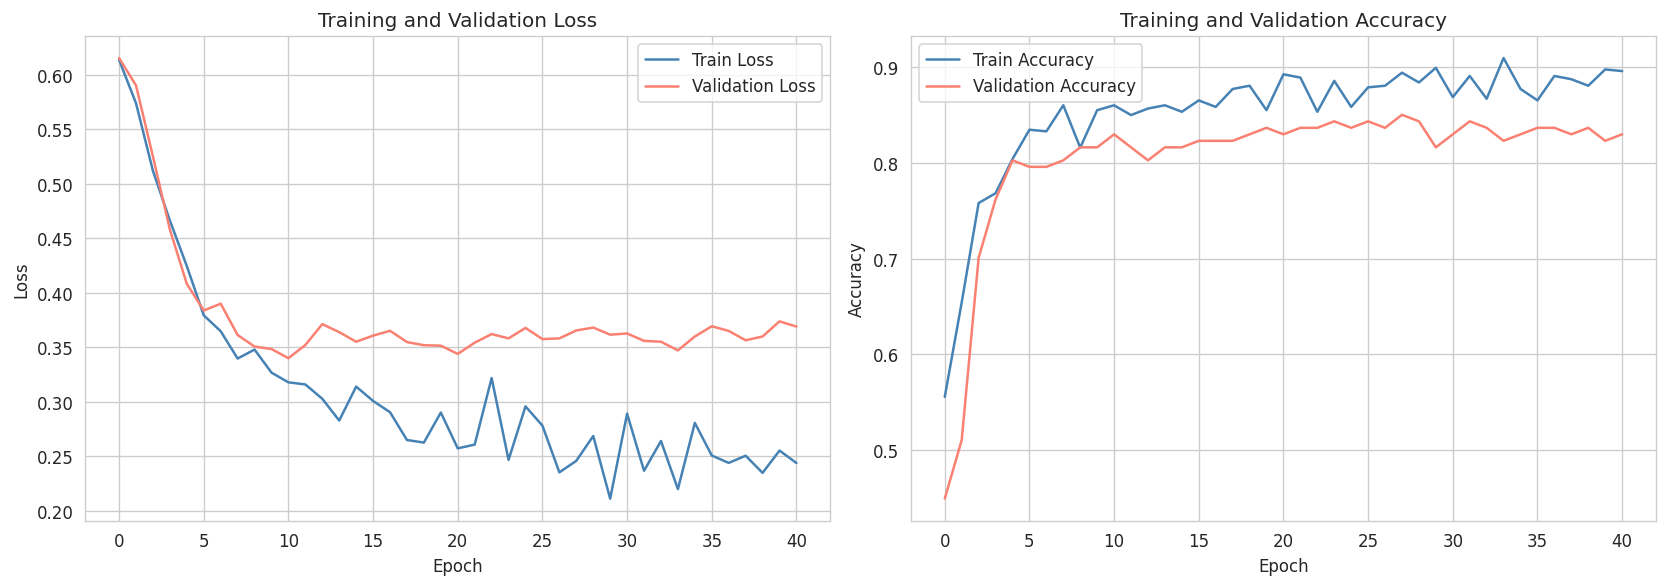

In [9]:
# =============================================================================
# 7b. TRAINING CURVES
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(train_losses, label='Train Loss', color='steelblue')
ax1.plot(val_losses, label='Validation Loss', color='salmon')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy curves
ax2.plot(train_accs, label='Train Accuracy', color='steelblue')
ax2.plot(val_accs, label='Validation Accuracy', color='salmon')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 8. Stratified K-Fold Cross-Validation

To get a robust estimate of generalisation performance on a small dataset, we run 5-fold stratified cross-validation and report mean and standard deviation of key metrics.

In [10]:
# =============================================================================
# 8. STRATIFIED K-FOLD CROSS-VALIDATION
# =============================================================================

def run_cv(X_full, y_full, feature_names, n_splits=5):
    """Run stratified k-fold CV and return per-fold metrics."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    
    fold_results = {'accuracy': [], 'precision': [], 'recall': [],
                    'f1': [], 'roc_auc': []}
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full)):
        X_tr = X_full[train_idx].astype(np.float32).copy()
        X_va = X_full[val_idx].astype(np.float32).copy()
        y_tr, y_va = y_full[train_idx], y_full[val_idx]
        
        # Scale within fold
        sc = StandardScaler()
        num_idx = [feature_names.index(c) for c in numeric_features]
        X_tr[:, num_idx] = sc.fit_transform(X_tr[:, num_idx])
        X_va[:, num_idx] = sc.transform(X_va[:, num_idx])
        
        # Class weights for this fold
        cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr)
        cw_dict = {0: float(cw[0]), 1: float(cw[1])}
        pos_w = torch.FloatTensor([cw_dict[1] / cw_dict[0]]).to(device)
        
        # Build model
        fold_model = HeartDiseaseNet(input_dim=X_tr.shape[1], hidden_dim=128,
                                     n_blocks=3, dropout=0.4).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
        opt = optim.AdamW(fold_model.parameters(), lr=1e-3, weight_decay=1e-4)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=200, eta_min=1e-6)
        
        # Tensors
        Xt = torch.FloatTensor(X_tr).to(device)
        yt = torch.FloatTensor(y_tr.astype(np.float32)).to(device)
        Xv = torch.FloatTensor(X_va).to(device)
        
        # Weighted sampler
        sw = np.array([cw_dict[int(l)] for l in y_tr])
        sampler = WeightedRandomSampler(torch.DoubleTensor(sw), len(sw), replacement=True)
        loader = DataLoader(TensorDataset(Xt, yt), batch_size=64, sampler=sampler)
        
        # Train (silent)
        best_vl = float('inf')
        best_state = None
        no_improv = 0
        for ep in range(200):
            fold_model.train()
            for xb, yb in loader:
                opt.zero_grad()
                loss = criterion(fold_model(xb).squeeze(), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
                opt.step()
            sched.step()
            
            fold_model.eval()
            with torch.no_grad():
                vl = criterion(fold_model(Xv).squeeze(),
                               torch.FloatTensor(y_va.astype(np.float32)).to(device)).item()
            if vl < best_vl:
                best_vl = vl
                best_state = fold_model.state_dict().copy()
                no_improv = 0
            else:
                no_improv += 1
            if no_improv >= 25:
                break
        
        fold_model.load_state_dict(best_state)
        fold_model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(fold_model(Xv).squeeze()).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        
        fold_results['accuracy'].append(accuracy_score(y_va, preds))
        fold_results['precision'].append(precision_score(y_va, preds))
        fold_results['recall'].append(recall_score(y_va, preds))
        fold_results['f1'].append(f1_score(y_va, preds))
        fold_results['roc_auc'].append(roc_auc_score(y_va, probs))
        
        print(f"Fold {fold+1}: Acc={fold_results['accuracy'][-1]:.4f}  "
              f"F1={fold_results['f1'][-1]:.4f}  "
              f"Recall={fold_results['recall'][-1]:.4f}  "
              f"AUC={fold_results['roc_auc'][-1]:.4f}")
    
    print(f"\n{'Metric':<12} {'Mean':>8} {'Std':>8}")
    print("-" * 30)
    for metric in fold_results:
        vals = fold_results[metric]
        print(f"{metric:<12} {np.mean(vals):>8.4f} {np.std(vals):>8.4f}")
    
    return fold_results

# Use the pre-encoded data (before scaling) for CV
X_cv = heart_encoded.drop('HeartDisease', axis=1).values.astype(np.float32).copy()
y_cv = heart_encoded['HeartDisease'].values.astype(np.float32).copy()
cv_results = run_cv(X_cv, y_cv, feature_names)

Fold 1: Acc=0.9022  F1=0.9082  Recall=0.8725  AUC=0.9440


Fold 2: Acc=0.8152  F1=0.8172  Recall=0.7451  AUC=0.9305


Fold 3: Acc=0.8315  F1=0.8488  Recall=0.8529  AUC=0.8812


Fold 4: Acc=0.8907  F1=0.8980  Recall=0.8713  AUC=0.9327


Fold 5: Acc=0.8415  F1=0.8599  Recall=0.8812  AUC=0.9088

Metric           Mean      Std
------------------------------
accuracy       0.8562   0.0341
precision      0.8924   0.0432
recall         0.8446   0.0506
f1             0.8664   0.0332
roc_auc        0.9195   0.0223


## 9. Test Set Evaluation

Full evaluation on the held-out test set using the best model from training:
- Classification report (accuracy, precision, recall, F1)
- ROC-AUC and Precision-Recall AUC
- Confusion matrix
- Calibration curve

In [11]:
# =============================================================================
# 9. TEST SET EVALUATION
# =============================================================================

model.eval()
with torch.no_grad():
    test_logits = model(X_test_t).squeeze()
    test_probs = torch.sigmoid(test_logits).cpu().numpy()

test_preds = (test_probs >= 0.5).astype(int)
y_test_np = y_test

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT (Test Set, threshold = 0.5)")
print("=" * 60)
print(classification_report(y_test_np, test_preds,
                            target_names=['No Disease (0)', 'Disease (1)']))

# Key metrics
acc = accuracy_score(y_test_np, test_preds)
prec = precision_score(y_test_np, test_preds)
rec = recall_score(y_test_np, test_preds)
f1 = f1_score(y_test_np, test_preds)
roc = roc_auc_score(y_test_np, test_probs)
ap = average_precision_score(y_test_np, test_probs)

print(f"Accuracy:            {acc:.4f}")
print(f"Precision (Disease): {prec:.4f}")
print(f"Recall (Disease):    {rec:.4f}")
print(f"F1-Score (Disease):  {f1:.4f}")
print(f"ROC-AUC:             {roc:.4f}")
print(f"Average Precision:   {ap:.4f}")

CLASSIFICATION REPORT (Test Set, threshold = 0.5)
                precision    recall  f1-score   support

No Disease (0)       0.79      0.93      0.85        82
   Disease (1)       0.93      0.80      0.86       102

      accuracy                           0.86       184
     macro avg       0.86      0.87      0.86       184
  weighted avg       0.87      0.86      0.86       184

Accuracy:            0.8587
Precision (Disease): 0.9318
Recall (Disease):    0.8039
F1-Score (Disease):  0.8632
ROC-AUC:             0.9224
Average Precision:   0.9161


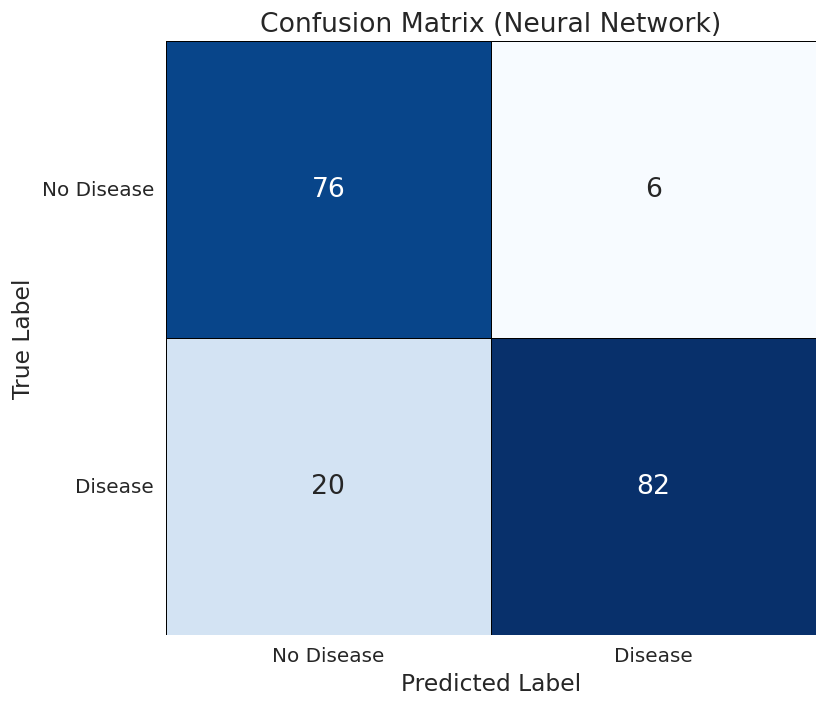

True Negatives:  76 (correctly predicted No Disease)
False Positives: 6 (incorrectly predicted Disease)
False Negatives: 20 (MISSED disease cases - most critical)
True Positives:  82 (correctly predicted Disease)


In [12]:
# =============================================================================
# 9b. CONFUSION MATRIX
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_np, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            linewidths=0.5, linecolor='black', annot_kws={"size": 16}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('Confusion Matrix (Neural Network)', fontsize=16)
ax.set_xticklabels(['No Disease', 'Disease'], fontsize=12)
ax.set_yticklabels(['No Disease', 'Disease'], fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# Print confusion matrix interpretation
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn} (correctly predicted No Disease)")
print(f"False Positives: {fp} (incorrectly predicted Disease)")
print(f"False Negatives: {fn} (MISSED disease cases - most critical)")
print(f"True Positives:  {tp} (correctly predicted Disease)")

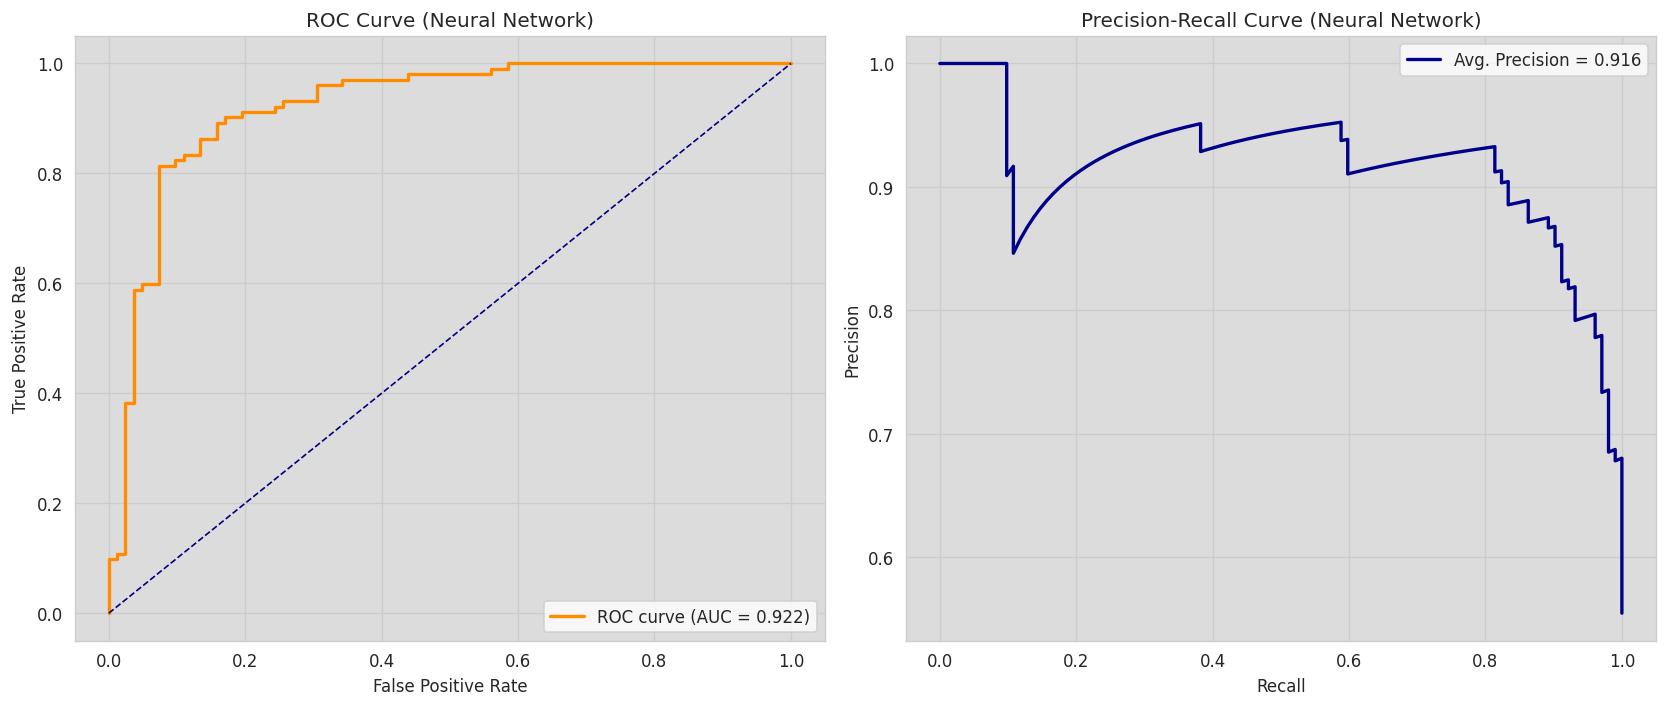

In [13]:
# =============================================================================
# 9c. ROC CURVE AND PRECISION-RECALL CURVE
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_np, test_probs)
ax1.set_facecolor(plt.cm.coolwarm(0.5))
ax1.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve (Neural Network)')
ax1.legend(loc='lower right')
ax1.grid(True)

# Precision-Recall Curve
precision_curve, recall_curve_vals, _ = precision_recall_curve(y_test_np, test_probs)
ax2.set_facecolor(plt.cm.coolwarm(0.5))
ax2.plot(recall_curve_vals, precision_curve, color='darkblue', lw=2,
         label=f'Avg. Precision = {ap:.3f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (Neural Network)')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

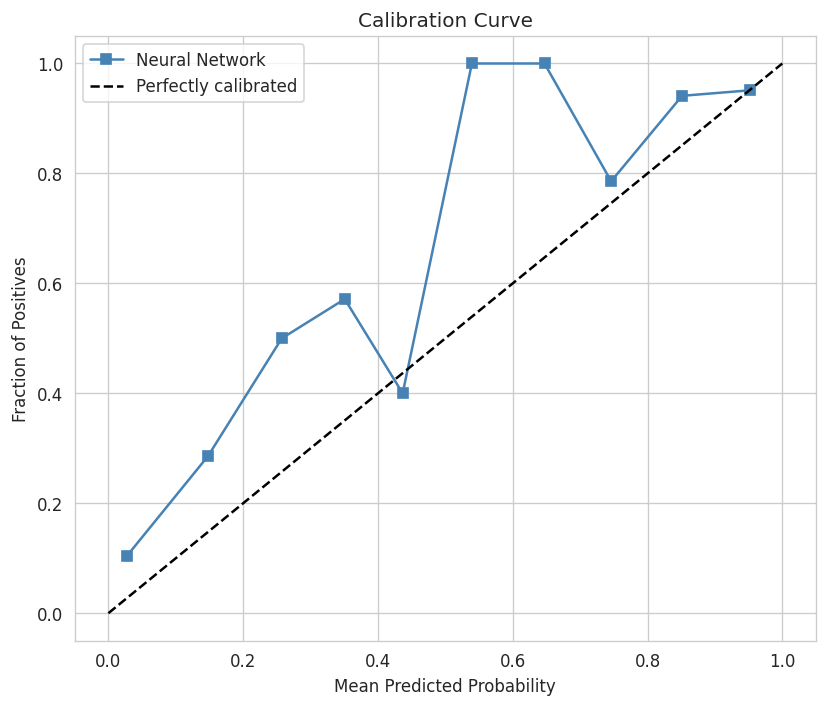

In [14]:
# =============================================================================
# 9d. CALIBRATION CURVE
# =============================================================================
# Calibration measures how well predicted probabilities match actual outcomes.
# A well-calibrated model's curve follows the diagonal.

fig, ax = plt.subplots(figsize=(7, 6))
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test_np, test_probs, n_bins=10, strategy='uniform')

ax.plot(mean_predicted_value, fraction_of_positives, 's-', color='steelblue',
        label='Neural Network')
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

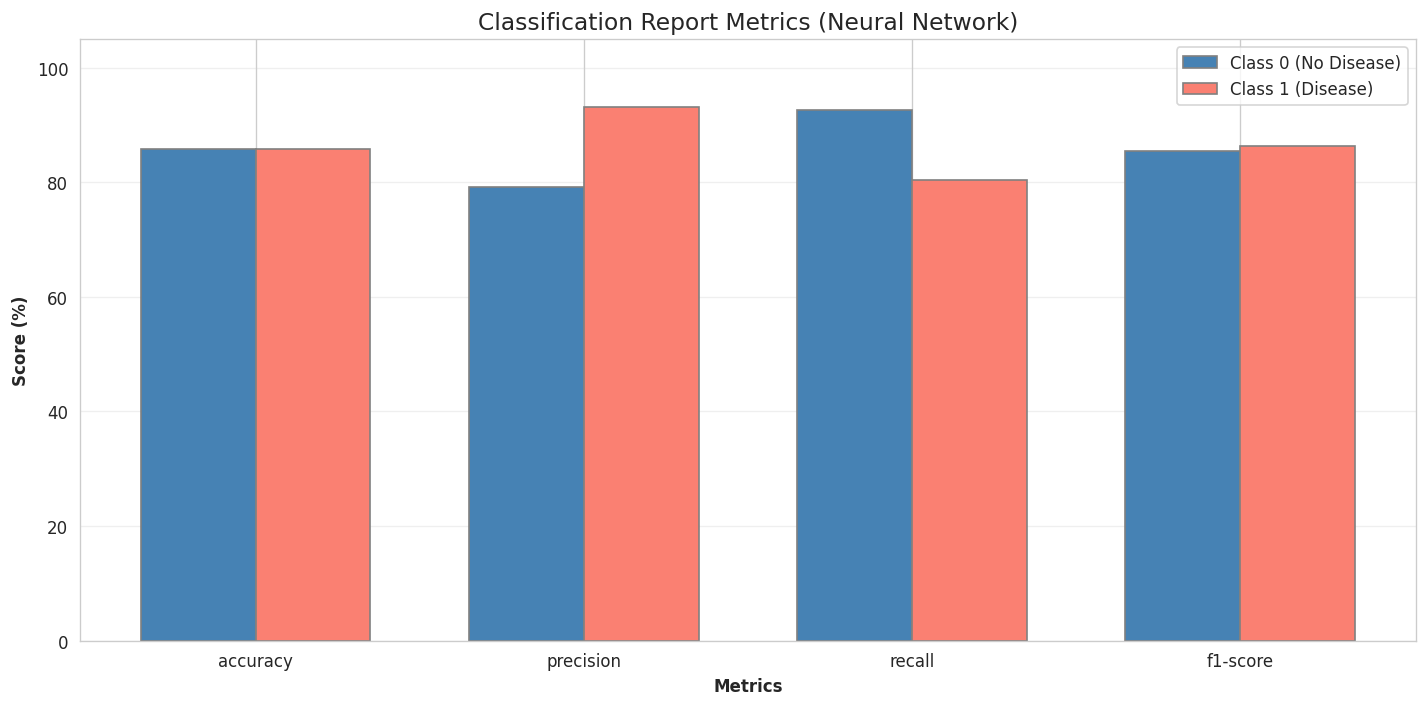

In [15]:
# =============================================================================
# 9e. METRICS BAR CHART (matching Random Forest notebook style)
# =============================================================================
report = classification_report(y_test_np, test_preds, output_dict=True)
accuracy_percent = report['accuracy'] * 100

# Find the class keys (may be '0'/'1' or '0.0'/'1.0' depending on dtype)
class_0_key = '0' if '0' in report else '0.0'
class_1_key = '1' if '1' in report else '1.0'

barWidth = 0.35
metrics_list = ['accuracy', 'precision', 'recall', 'f1-score']

class_0_vals = [accuracy_percent if m == 'accuracy' else report[class_0_key][m] * 100
                for m in metrics_list]
class_1_vals = [accuracy_percent if m == 'accuracy' else report[class_1_key][m] * 100
                for m in metrics_list]

r1 = np.arange(len(class_0_vals))
r2 = [x + barWidth for x in r1]

plt.figure(figsize=(12, 6))
plt.bar(r1, class_0_vals, width=barWidth, color='steelblue', edgecolor='grey',
        label='Class 0 (No Disease)')
plt.bar(r2, class_1_vals, width=barWidth, color='salmon', edgecolor='grey',
        label='Class 1 (Disease)')
plt.xlabel('Metrics', fontweight='bold')
plt.ylabel('Score (%)', fontweight='bold')
plt.xticks([r + barWidth/2 for r in range(len(class_0_vals))], metrics_list)
plt.title('Classification Report Metrics (Neural Network)', fontsize=14)
plt.legend()
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Clinical Threshold Optimisation

In heart disease screening, **false negatives are far more dangerous than false positives** — missing a person who has heart disease could be fatal, while a false alarm leads to additional (harmless) testing.

We sweep decision thresholds from 0 to 1 and find:
1. The threshold that maximises the **F1-score**
2. The threshold that achieves a target **recall >= 0.90** with the best possible precision
3. The **Youden's J** optimal point on the ROC curve

THRESHOLD ANALYSIS

1. Best F1 threshold:       0.24
   Accuracy=0.8641  Precision=0.8598  Recall=0.9020  F1=0.8804

2. Clinical threshold (recall >= 0.90): 0.24
   Accuracy=0.8641  Precision=0.8598  Recall=0.9020  F1=0.8804

3. Youden's J threshold:    0.48
   Youden's J = 0.7406


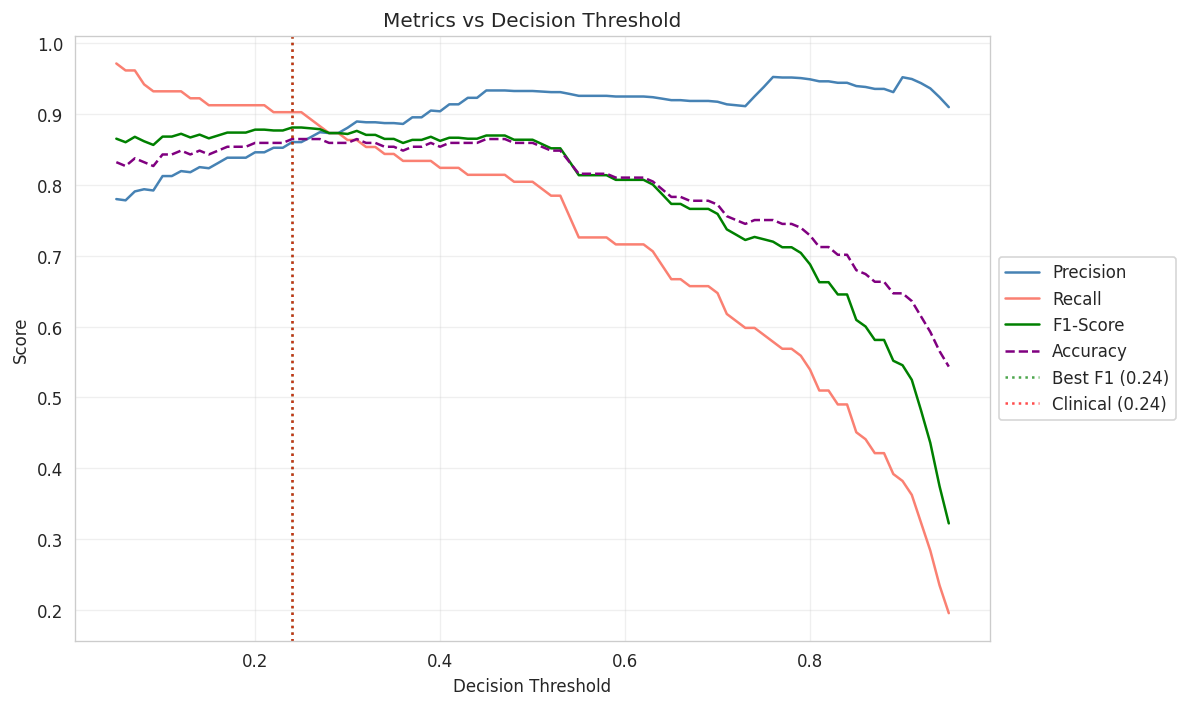


Confusion Matrix at clinical threshold = 0.24:
  TN=67  FP=15  FN=10  TP=92
  Recall = 0.9020 (only 10 missed disease cases)


In [16]:
# =============================================================================
# 10. CLINICAL THRESHOLD OPTIMISATION
# =============================================================================

thresholds = np.arange(0.05, 0.96, 0.01)
results = []
for t in thresholds:
    preds_t = (test_probs >= t).astype(int)
    results.append({
        'threshold': t,
        'accuracy': accuracy_score(y_test_np, preds_t),
        'precision': precision_score(y_test_np, preds_t, zero_division=0),
        'recall': recall_score(y_test_np, preds_t, zero_division=0),
        'f1': f1_score(y_test_np, preds_t, zero_division=0),
    })
thresh_df = pd.DataFrame(results)

# Best F1 threshold
best_f1_row = thresh_df.loc[thresh_df['f1'].idxmax()]
# Best recall >= 0.90 with highest precision
high_recall = thresh_df[thresh_df['recall'] >= 0.90]
if len(high_recall) > 0:
    best_clinical_row = high_recall.loc[high_recall['precision'].idxmax()]
else:
    best_clinical_row = thresh_df.loc[thresh_df['recall'].idxmax()]

# Youden's J statistic (optimal ROC point)
fpr_full, tpr_full, roc_thresholds = roc_curve(y_test_np, test_probs)
j_scores = tpr_full - fpr_full
best_j_idx = np.argmax(j_scores)
best_j_threshold = roc_thresholds[best_j_idx]

print("=" * 65)
print("THRESHOLD ANALYSIS")
print("=" * 65)
print(f"\n1. Best F1 threshold:       {best_f1_row['threshold']:.2f}")
print(f"   Accuracy={best_f1_row['accuracy']:.4f}  Precision={best_f1_row['precision']:.4f}  "
      f"Recall={best_f1_row['recall']:.4f}  F1={best_f1_row['f1']:.4f}")

print(f"\n2. Clinical threshold (recall >= 0.90): {best_clinical_row['threshold']:.2f}")
print(f"   Accuracy={best_clinical_row['accuracy']:.4f}  Precision={best_clinical_row['precision']:.4f}  "
      f"Recall={best_clinical_row['recall']:.4f}  F1={best_clinical_row['f1']:.4f}")

print(f"\n3. Youden's J threshold:    {best_j_threshold:.2f}")
print(f"   Youden's J = {j_scores[best_j_idx]:.4f}")

# Plot threshold sweep
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='steelblue')
ax.plot(thresh_df['threshold'], thresh_df['recall'], label='Recall', color='salmon')
ax.plot(thresh_df['threshold'], thresh_df['f1'], label='F1-Score', color='green')
ax.plot(thresh_df['threshold'], thresh_df['accuracy'], label='Accuracy', color='purple', linestyle='--')
ax.axvline(x=best_f1_row['threshold'], color='green', linestyle=':', alpha=0.7,
           label=f"Best F1 ({best_f1_row['threshold']:.2f})")
ax.axvline(x=best_clinical_row['threshold'], color='red', linestyle=':', alpha=0.7,
           label=f"Clinical ({best_clinical_row['threshold']:.2f})")
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Decision Threshold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show confusion matrix at clinical threshold
clinical_threshold = best_clinical_row['threshold']
clinical_preds = (test_probs >= clinical_threshold).astype(int)
print(f"\nConfusion Matrix at clinical threshold = {clinical_threshold:.2f}:")
cm_clinical = confusion_matrix(y_test_np, clinical_preds)
tn_c, fp_c, fn_c, tp_c = cm_clinical.ravel()
print(f"  TN={tn_c}  FP={fp_c}  FN={fn_c}  TP={tp_c}")
print(f"  Recall = {recall_score(y_test_np, clinical_preds):.4f} "
      f"(only {fn_c} missed disease cases)")

## 11. Feature Importance — SHAP Analysis

SHAP (SHapley Additive exPlanations) provides model-agnostic interpretability by computing the contribution of each feature to individual predictions. We use the `DeepExplainer` (or `KernelExplainer` as fallback) to explain our neural network.

In [17]:
# =============================================================================
# 11. FEATURE IMPORTANCE — SHAP ANALYSIS
# =============================================================================

model.eval()

# Use a background sample from training data for SHAP
background = X_train_t[:100]

# Wrap model to output probabilities (sigmoid applied)
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return torch.sigmoid(self.model(x))

wrapped_model = ModelWrapper(model).to(device)
wrapped_model.eval()

# Try DeepExplainer first, fall back to KernelExplainer
try:
    explainer = shap.DeepExplainer(wrapped_model, background)
    shap_values = explainer.shap_values(X_test_t)
    print("Used SHAP DeepExplainer")
except Exception as e:
    print(f"DeepExplainer failed ({e}), using KernelExplainer instead...")
    def model_predict(x):
        with torch.no_grad():
            t = torch.FloatTensor(x).to(device)
            return torch.sigmoid(model(t)).cpu().numpy()
    explainer = shap.KernelExplainer(model_predict, background.cpu().numpy())
    shap_values = explainer.shap_values(X_test.values.astype(np.float32), nsamples=200)
    print("Used SHAP KernelExplainer")

# Convert to numpy if needed
if isinstance(shap_values, list):
    shap_values = shap_values[0]
if isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.cpu().numpy()

# Ensure 2D shape (samples x features)
if shap_values.ndim == 3:
    shap_values = shap_values.squeeze(-1)  # Remove extra output dim
    
print(f"SHAP values shape: {shap_values.shape}")

DeepExplainer failed (The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 0.24642674555434496 - Tolerance: 0.01), using KernelExplainer instead...


  0%|          | 0/184 [00:00<?, ?it/s]

Used SHAP KernelExplainer
SHAP values shape: (184, 20)


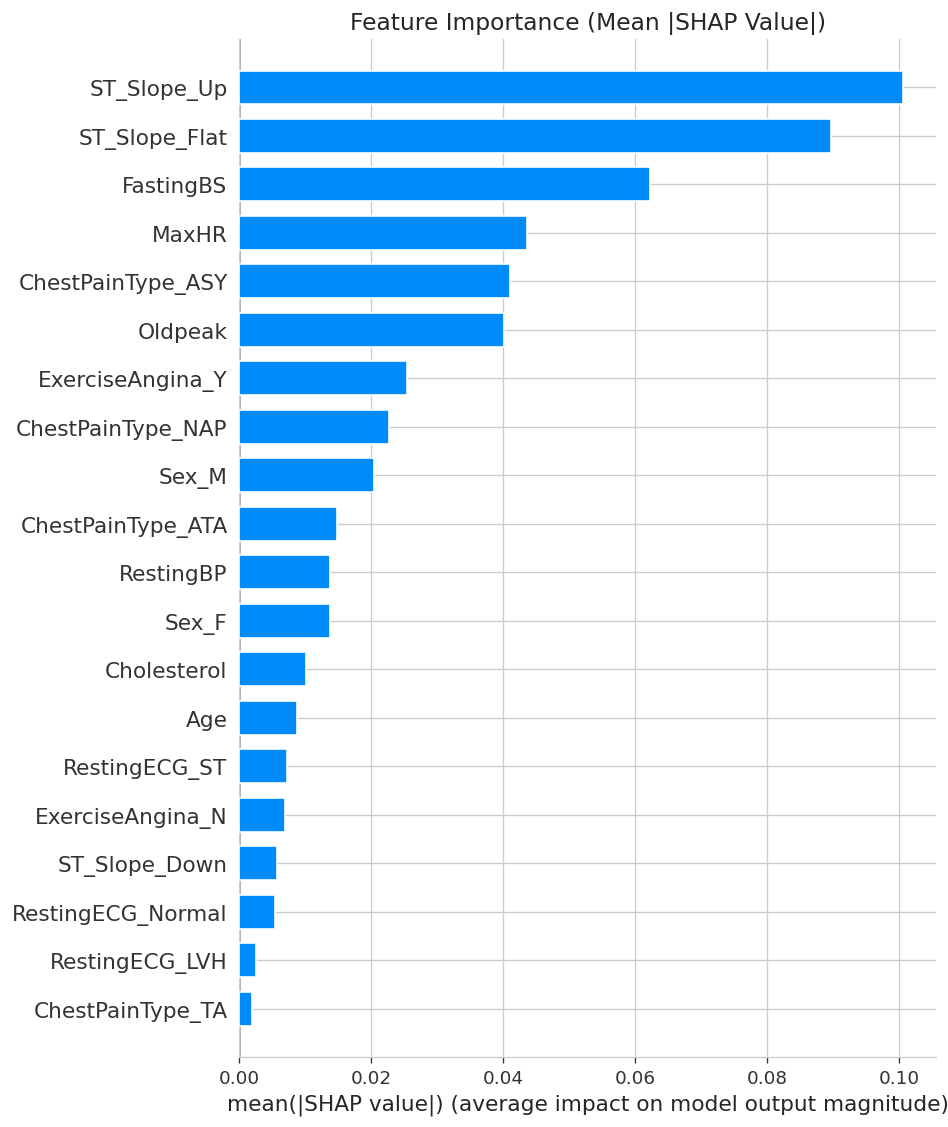

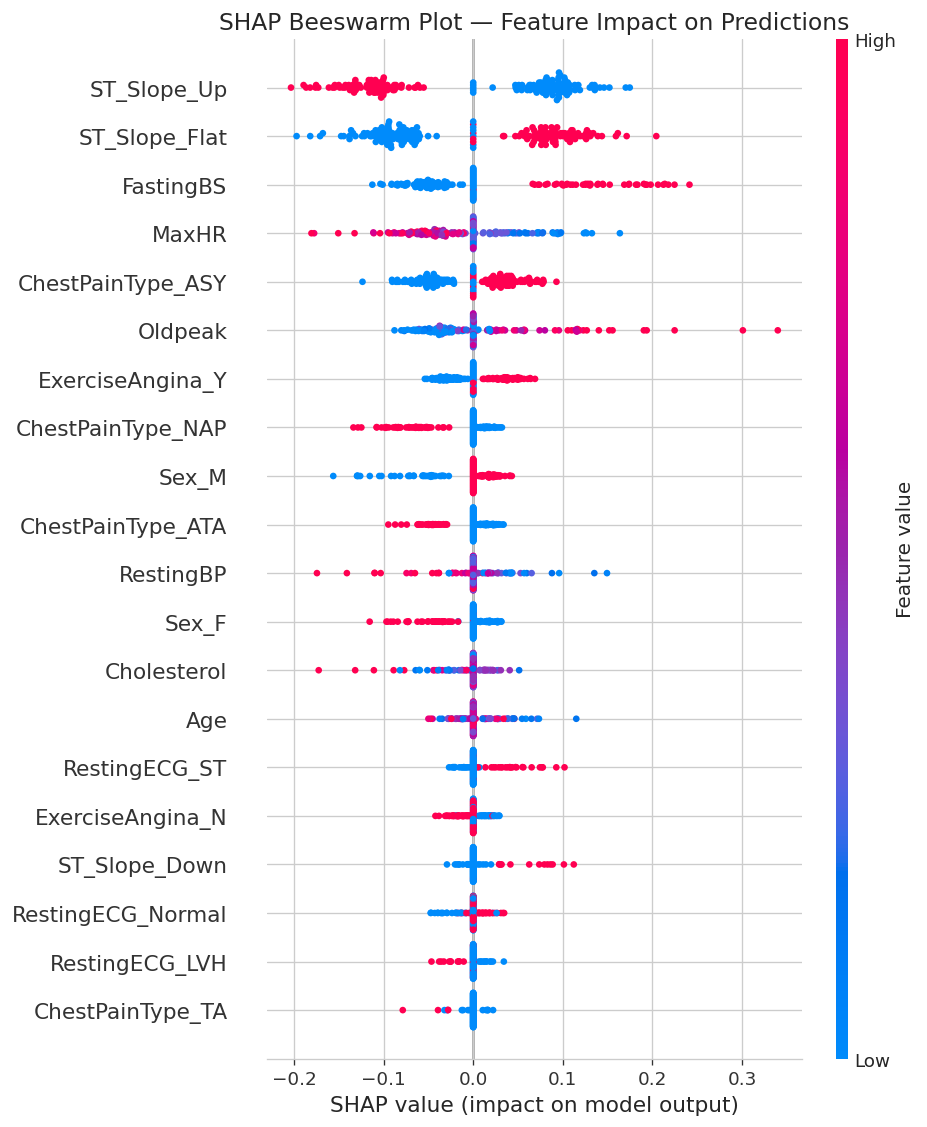


Top 10 Most Important Features (by mean |SHAP|):
---------------------------------------------
  ST_Slope_Up               0.1006
  ST_Slope_Flat             0.0897
  FastingBS                 0.0623
  MaxHR                     0.0436
  ChestPainType_ASY         0.0410
  Oldpeak                   0.0402
  ExerciseAngina_Y          0.0254
  ChestPainType_NAP         0.0227
  Sex_M                     0.0205
  ChestPainType_ATA         0.0149


In [18]:
# =============================================================================
# 11b. SHAP PLOTS
# =============================================================================

X_test_display = X_test.values.astype(np.float32)

# Summary bar plot (mean absolute SHAP value per feature)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_display, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("Feature Importance (Mean |SHAP Value|)", fontsize=14)
plt.tight_layout()
plt.show()

# Beeswarm plot (shows direction and magnitude of feature effects)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_display, feature_names=feature_names, show=False)
plt.title("SHAP Beeswarm Plot — Feature Impact on Predictions", fontsize=14)
plt.tight_layout()
plt.show()

# Print top 10 most important features
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap.flatten()
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 10 Most Important Features (by mean |SHAP|):")
print("-" * 45)
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:<25s} {row['mean_abs_shap']:.4f}")

## 12. Prediction Output

Generate a table showing each test-set patient with their predicted risk status and probability.

In [19]:
# =============================================================================
# 12. PREDICTION OUTPUT
# =============================================================================

# Use the clinical threshold for final predictions
prediction_df = pd.DataFrame({
    'Patient_Index': X_test.index,
    'True_Label': y_test_np,
    'Predicted_Probability': np.round(test_probs, 4),
    'Predicted_Label_0.5': test_preds,
    'Predicted_Label_Clinical': (test_probs >= clinical_threshold).astype(int),
})
prediction_df['Risk_Status_0.5'] = prediction_df['Predicted_Label_0.5'].map(
    {0: 'Not At Risk', 1: 'At Risk'})
prediction_df['Risk_Status_Clinical'] = prediction_df['Predicted_Label_Clinical'].map(
    {0: 'Not At Risk', 1: 'At Risk'})
prediction_df['Correct_0.5'] = prediction_df['True_Label'] == prediction_df['Predicted_Label_0.5']
prediction_df['Correct_Clinical'] = prediction_df['True_Label'] == prediction_df['Predicted_Label_Clinical']

print(f"Prediction results (test set, n={len(prediction_df)}):")
print(f"Clinical threshold used: {clinical_threshold:.2f}")
display(prediction_df.head(20))

print(f"\nSummary at threshold = 0.5:")
print(f"  Correct: {prediction_df['Correct_0.5'].sum()} / {len(prediction_df)} "
      f"({prediction_df['Correct_0.5'].mean()*100:.1f}%)")

print(f"\nSummary at clinical threshold = {clinical_threshold:.2f}:")
print(f"  Correct: {prediction_df['Correct_Clinical'].sum()} / {len(prediction_df)} "
      f"({prediction_df['Correct_Clinical'].mean()*100:.1f}%)")

# Save predictions to CSV
prediction_df.to_csv('neural_network_predictions.csv', index=False)
print("\nPredictions saved to 'neural_network_predictions.csv'")

Prediction results (test set, n=184):
Clinical threshold used: 0.24


,Patient_Index,True_Label,Predicted_Probability,Predicted_Label_0.5,Predicted_Label_Clinical,Risk_Status_0.5,Risk_Status_Clinical,Correct_0.5,Correct_Clinical
0,356,1.0,0.9447,1,1,At Risk,At Risk,True,True
1,763,1.0,0.1435,0,0,Not At Risk,Not At Risk,False,False
2,817,1.0,0.7540,1,1,At Risk,At Risk,True,True
3,735,1.0,0.3906,0,1,Not At Risk,At Risk,False,True
4,892,0.0,0.1323,0,0,Not At Risk,Not At Risk,True,True
5,795,0.0,0.2964,0,1,Not At Risk,At Risk,True,False
6,234,0.0,0.0176,0,0,Not At Risk,Not At Risk,True,True
7,383,1.0,0.5043,1,1,At Risk,At Risk,True,True
8,642,0.0,0.0250,0,0,Not At Risk,Not At Risk,True,True
9,454,1.0,0.9662,1,1,At Risk,At Risk,True,True



Summary at threshold = 0.5:
  Correct: 158 / 184 (85.9%)

Summary at clinical threshold = 0.24:
  Correct: 159 / 184 (86.4%)

Predictions saved to 'neural_network_predictions.csv'


## 13. PCA Visualisation and Decision Boundary

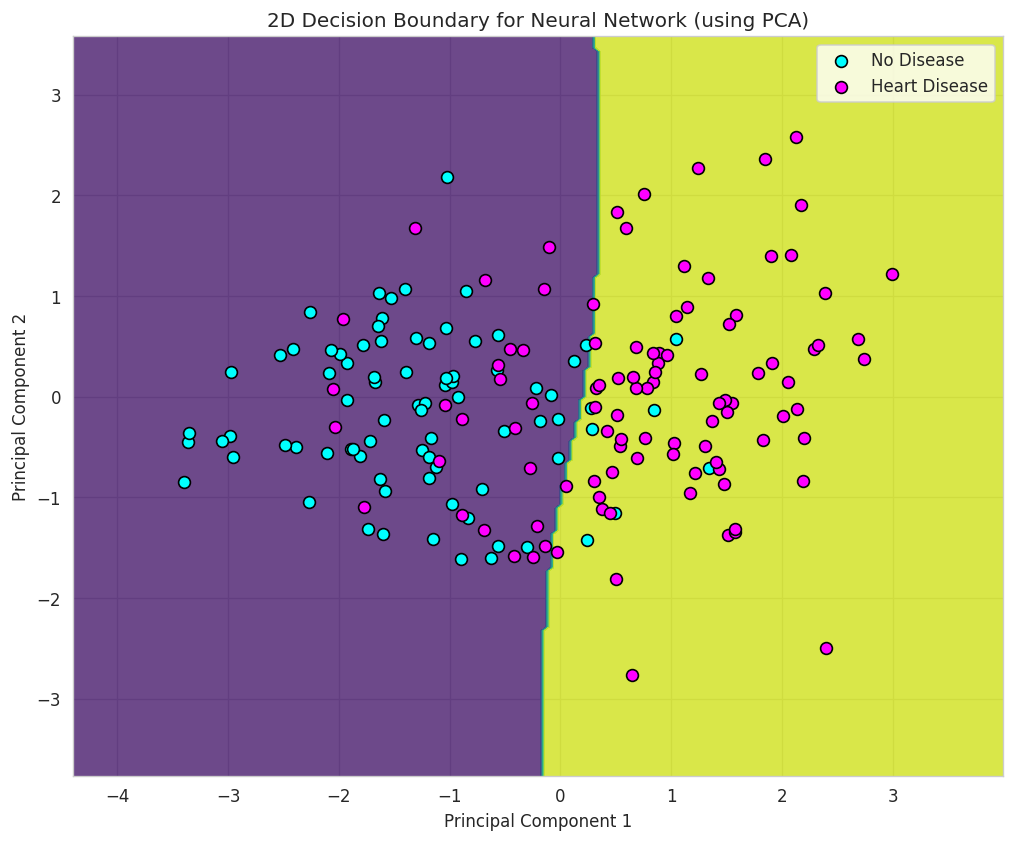

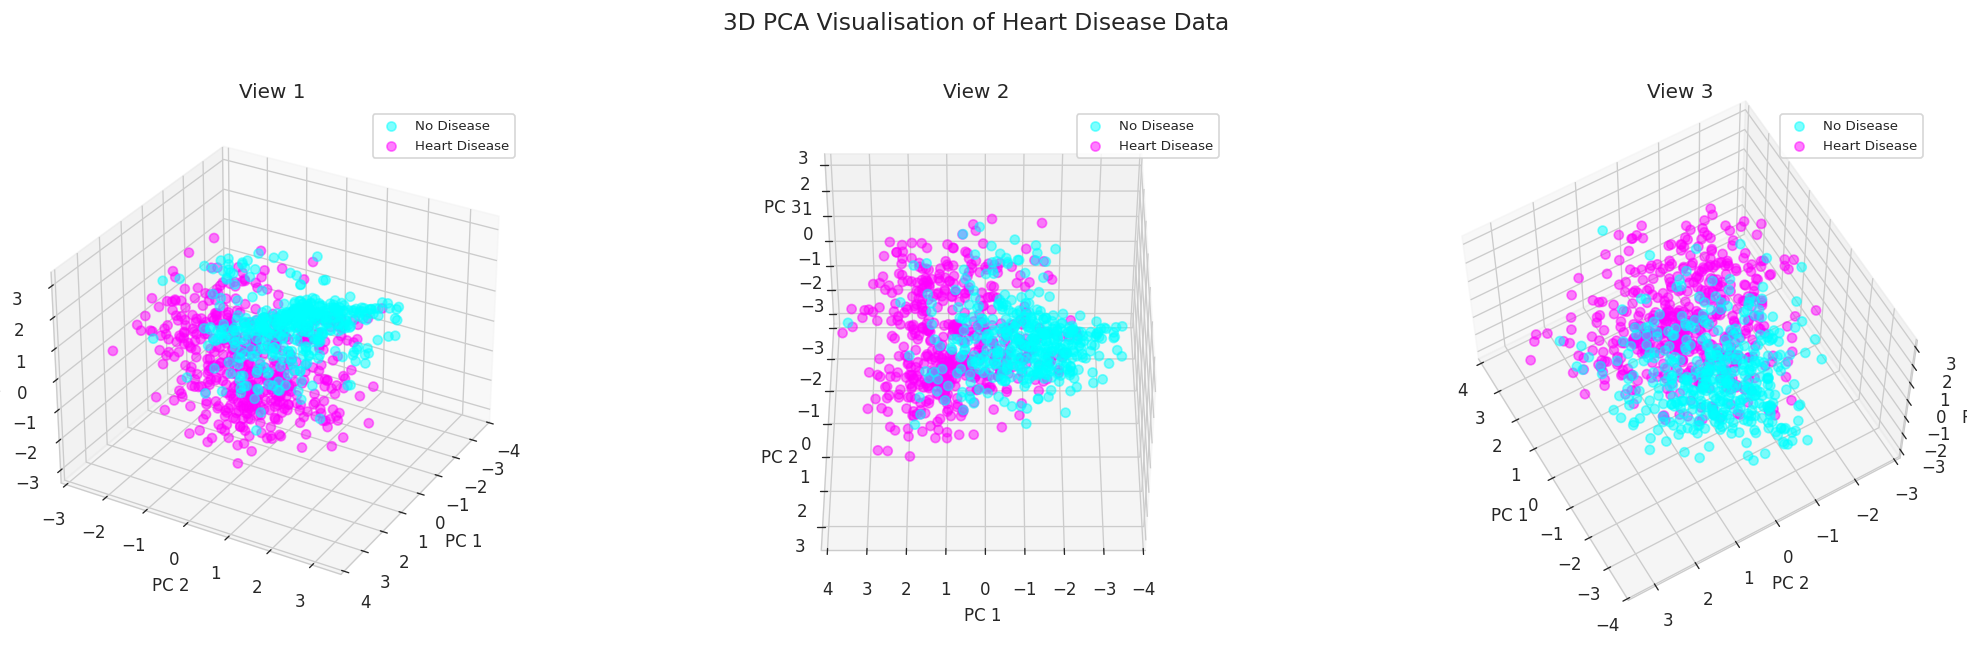

In [20]:
# =============================================================================
# 13. PCA VISUALISATION AND DECISION BOUNDARY
# =============================================================================
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# 2D PCA decision boundary
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train.values)
X_test_pca = pca_2d.transform(X_test.values)

# Train a small NN on PCA features for visualisation
pca_model = HeartDiseaseNet(input_dim=2, hidden_dim=32, n_blocks=2, dropout=0.3).to(device)
pca_opt = optim.AdamW(pca_model.parameters(), lr=1e-3, weight_decay=1e-4)
pos_weight = torch.FloatTensor([class_weight_dict[1] / class_weight_dict[0]]).to(device)
pca_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Xt_pca = torch.FloatTensor(X_train_pca).to(device)
yt_pca = torch.FloatTensor(y_train).to(device)

pca_model.train()
for ep in range(200):
    pca_opt.zero_grad()
    loss = pca_criterion(pca_model(Xt_pca).squeeze(), yt_pca)
    loss.backward()
    pca_opt.step()

# Create mesh grid
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

pca_model.eval()
with torch.no_grad():
    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
    Z = (torch.sigmoid(pca_model(grid_tensor).squeeze()) >= 0.5).cpu().numpy().astype(int)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.viridis)
mask_0 = y_test == 0
mask_1 = y_test == 1
plt.scatter(X_test_pca[mask_0, 0], X_test_pca[mask_0, 1], color='cyan',
            label='No Disease', marker='o', s=50, edgecolor='k')
plt.scatter(X_test_pca[mask_1, 0], X_test_pca[mask_1, 1], color='magenta',
            label='Heart Disease', marker='o', s=50, edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D Decision Boundary for Neural Network (using PCA)')
plt.legend()
plt.grid(True)
plt.show()

# 3D PCA visualisation
pca_3d = PCA(n_components=3)
X_all_scaled = np.vstack([X_train.values, X_val.values, X_test.values])
y_all = np.concatenate([y_train, y_val, y_test])
X_pca_3d = pca_3d.fit_transform(X_all_scaled)

fig = plt.figure(figsize=(18, 5))
for idx, angle in enumerate([(30, 30), (45, 90), (60, 150)]):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    ax.scatter(X_pca_3d[y_all == 0, 0], X_pca_3d[y_all == 0, 1], X_pca_3d[y_all == 0, 2],
               color='cyan', s=30, label='No Disease', alpha=0.5)
    ax.scatter(X_pca_3d[y_all == 1, 0], X_pca_3d[y_all == 1, 1], X_pca_3d[y_all == 1, 2],
               color='magenta', s=30, label='Heart Disease', alpha=0.5)
    ax.view_init(elev=angle[0], azim=angle[1])
    ax.set_title(f'View {idx + 1}')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.set_zlabel('PC 3')
    ax.legend(fontsize=8)
plt.suptitle("3D PCA Visualisation of Heart Disease Data", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 14. Summary and Conclusions

In [21]:
# =============================================================================
# 14. SUMMARY AND CONCLUSIONS
# =============================================================================

print("=" * 70)
print("FINAL MODEL SUMMARY — Heart Disease Neural Network Classifier")
print("=" * 70)

print(f"""
DATASET:
  - 918 patient records, 11 input features (5 numeric, 6 categorical)
  - Target: HeartDisease (binary: 0 = no disease, 1 = disease)
  - After cleaning: {len(heart_data)} records

MODEL ARCHITECTURE:
  - Deep feedforward neural network with residual (skip) connections
  - 3 residual blocks, 128 hidden units, GELU activation
  - BatchNorm + Dropout (0.4) for regularisation
  - Total parameters: {total_params:,}
  - Framework: PyTorch

TRAINING:
  - AdamW optimiser with cosine annealing LR schedule
  - Weighted BCE loss to handle class imbalance
  - WeightedRandomSampler for balanced mini-batches
  - Early stopping on validation loss (patience = 30)

TEST SET RESULTS (threshold = 0.5):
  - Accuracy:            {acc:.4f}  ({acc*100:.1f}%)
  - Precision (Disease): {prec:.4f}
  - Recall (Disease):    {rec:.4f}
  - F1-Score (Disease):  {f1:.4f}
  - ROC-AUC:             {roc:.4f}

CROSS-VALIDATION (5-fold):
  - Mean Accuracy:  {np.mean(cv_results['accuracy']):.4f} +/- {np.std(cv_results['accuracy']):.4f}
  - Mean F1:        {np.mean(cv_results['f1']):.4f} +/- {np.std(cv_results['f1']):.4f}
  - Mean Recall:    {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}
  - Mean ROC-AUC:   {np.mean(cv_results['roc_auc']):.4f} +/- {np.std(cv_results['roc_auc']):.4f}

CLINICAL THRESHOLD:
  - Recommended clinical threshold: {clinical_threshold:.2f}
  - At this threshold: Recall = {recall_score(y_test_np, clinical_preds):.4f}, 
    only {fn_c} missed disease cases out of {tp_c + fn_c} actual cases

LIMITATIONS:
  - Small dataset (918 samples) limits the advantage of deep learning over
    simpler models like Random Forest or Gradient Boosting.
  - Neural networks require more careful tuning and are less interpretable
    than tree-based models, though SHAP helps bridge this gap.
  - The model should NOT be used as a standalone diagnostic tool but can
    serve as a screening support system alongside clinical judgement.

CONCLUSION:
  The neural network achieves strong classification performance with
  high recall for the disease class, which is critical for medical screening.
  With the clinical threshold, the model minimises false negatives
  (missed disease cases) at the cost of slightly more false positives,
  which is an appropriate tradeoff in healthcare.
""")

print("=" * 70)
print("END OF ANALYSIS")
print("=" * 70)

FINAL MODEL SUMMARY — Heart Disease Neural Network Classifier

DATASET:
  - 918 patient records, 11 input features (5 numeric, 6 categorical)
  - Target: HeartDisease (binary: 0 = no disease, 1 = disease)
  - After cleaning: 918 records

MODEL ARCHITECTURE:
  - Deep feedforward neural network with residual (skip) connections
  - 3 residual blocks, 128 hidden units, GELU activation
  - BatchNorm + Dropout (0.4) for regularisation
  - Total parameters: 114,113
  - Framework: PyTorch

TRAINING:
  - AdamW optimiser with cosine annealing LR schedule
  - Weighted BCE loss to handle class imbalance
  - WeightedRandomSampler for balanced mini-batches
  - Early stopping on validation loss (patience = 30)

TEST SET RESULTS (threshold = 0.5):
  - Accuracy:            0.8587  (85.9%)
  - Precision (Disease): 0.9318
  - Recall (Disease):    0.8039
  - F1-Score (Disease):  0.8632
  - ROC-AUC:             0.9224

CROSS-VALIDATION (5-fold):
  - Mean Accuracy:  0.8562 +/- 0.0341
  - Mean F1:        0.8